# BBM409 Assignment 3: Anomaly Detection in Machinery Sounds

**Student:** Ufuk Tanrıverdi  
**ID:** 2230356136  
**Course:** BBM409 Introduction to Machine Learning Lab, Spring 2026

## Problem

We are given the DCASE 2020 Challenge Task 2 development dataset, which contains recordings of six machine types: ToyCar, ToyConveyor, fan, pump, slider, and valve. The task is to decide, for a given test recording, whether the machine sounds *normal* or *anomalous*.

The setup has a twist we should consider though: **the training set contains only normal sounds**. No anomalous examples are available during training. This means we cannot treat the problem as standard binary classification. Instead, we need an approach that learns what "normal" looks like and flags anything that deviates.

## Approach

We use **autoencoders**. An autoencoder is a neural network trained to reconstruct its own input: it compresses the input into a low-dimensional "bottleneck" representation and then expands it back to the original shape. When trained only on normal data, the network learns compact patterns that describe normal sounds well. At test time:

- Normal sounds reconstruct accurately (low reconstruction error)
- Anomalous sounds reconstruct poorly (high reconstruction error) because the network has never learned their patterns

We use the reconstruction error as an **anomaly score** and threshold it to classify a sound as normal or anomalous. Evaluation is done with ROC-AUC, which avoids the need to pick a threshold up front.

## Four architectures (obligatory)

1. Single-layer neural network: input → bottleneck → output
2. MLP with two hidden layers: input → hidden → bottleneck → hidden → output
3. CNN with one convolutional layer and one fully connected layer
4. CNN with two convolutional layers and two fully connected layers

The MLP variants are implemented from scratch in NumPy to demonstrate understanding of forward and backward propagation. The CNN variants use PyTorch, which the assignment explicitly permits for the CNN section.

## Feature representations

Raw audio cannot be fed directly to an autoencoder. We compare three time-frequency representations:

- **Mel spectrogram**: the DCASE baseline's choice, mel-scale frequency bins
- **STFT spectrogram**: linear-frequency short-time Fourier transform
- **Wavelet scalogram**: continuous wavelet transform, trades frequency resolution for time resolution at high frequencies

## Scope

To keep the experiment count manageable, we develop and evaluate on **ToyCar**, which has the largest training set (4000 clips) and a balanced test set (1400 normal, 1059 anomalous).

## Environment

- Python 3.12, dependencies managed with `uv`
- PyTorch 2.11 with CUDA 12.8 for the CNN section
- Training runs on a server GPU (NVIDIA RTX 5000 Ada, 32GB)
- All random seeds fixed for reproducibility

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # before importing torch
# this is only for the machine I am using, this cell can be skipped on other machines with a single GPU
# it is important to set this before importing torch, otherwise torch will see all the GPUs and may not use the one I want

In [3]:
import sys
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

# Project code lives in a sibling ./code directory
sys.path.insert(0, os.path.abspath("code"))

from config import SEED
# Setting the seed value once and for all for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python       : {sys.version.split()[0]}")
print(f"NumPy        : {np.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"CUDA avail.  : {torch.cuda.is_available()}")
print(f"Device       : {device}")
if torch.cuda.is_available():
    print(f"GPU name     : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Python       : 3.12.2
NumPy        : 2.4.4
PyTorch      : 2.11.0+cu128
CUDA avail.  : True
Device       : cuda
GPU name     : NVIDIA RTX 5000 Ada Generation
GPU memory   : 33.8 GB


## Dataset overview

DCASE 2020 Task 2 splits each machine type into a `train/` directory (normal clips only) and a `test/` directory (normal + anomalous clips, labeled by filename prefix). Files are named:  
`normal_id_00_00000005.wav`  
`anomaly_id_00_00000005.wav`  

The `id_XX` part refers to a specific individual machine of that type. For example, the ToyCar type includes machines with IDs 01, 02, 03, 04. For this work, we pool all IDs of a machine type into a single autoencoder, which simplifies the experimental setup at a small cost in detection accuracy compared to per-ID models.


In [4]:
from pathlib import Path

DATA_ROOT = Path("./data")  # <-- set this to where you extracted DCASE
MACHINE_TYPES = ["ToyCar", "ToyConveyor", "fan", "pump", "slider", "valve"]

def count_files(machine_dir: Path) -> dict:
    """Count train/test files and split test into normal vs anomaly."""
    train = list((machine_dir / "train").glob("*.wav"))
    test = list((machine_dir / "test").glob("*.wav"))
    test_normal = [p for p in test if p.name.startswith("normal_")]
    test_anomaly = [p for p in test if p.name.startswith("anomaly_")]
    return {
        "train": len(train),
        "test_normal": len(test_normal),
        "test_anomaly": len(test_anomaly),
    }

# Summary table across all machine types
print(f"{'machine':<14} {'train':>7} {'test_normal':>12} {'test_anomaly':>13}")
print("-" * 50)
for mt in MACHINE_TYPES:
    counts = count_files(DATA_ROOT / mt)
    print(f"{mt:<14} {counts['train']:>7} {counts['test_normal']:>12} {counts['test_anomaly']:>13}")

machine          train  test_normal  test_anomaly
--------------------------------------------------
ToyCar            4000         1400          1059
ToyConveyor       3000         2399          1110
fan               3675          400          1475
pump              3349          400           456
slider            2804          400           890
valve             3291          400           479


## Feature Extraction

Raw audio is a 1-D waveform at 16,000 samples per second. One 10-second clip is 160,000 numbers. That is too many for an autoencoder input -- and more importantly, raw samples are not a good representation: a tiny time-shift changes every value even though the sound is perceptually identical.

We convert each clip to a **2-D time-frequency representation** (spectrogram). The x-axis is time, the y-axis is frequency, and each cell contains how strongly that frequency is present at that moment in dB. This is much more stable and compact.

We compare three representations:

| Feature | Freq. axis | How it is computed | Freq. bins | Time frames |
|---|---|---|---|---|
| **Mel spectrogram** | Non-linear (mel scale) | Short-time FFT, then mapped to mel filterbank | 64 | ~312 |
| **STFT spectrogram** | Linear | Magnitude of short-time FFT | 512 | ~312 |
| **Wavelet scalogram** | Log-scale (by scale) | Continuous Wavelet Transform, downsampled in time | 64 | ~312 |

**Why mel?** The mel scale compresses high frequencies (where adjacent bins differ by thousands of Hz) and expands low frequencies (where 50 Hz steps are perceptible). It matches how humans perceive pitch and is the DCASE baseline choice.

**Why STFT?** Uniform frequency resolution across the spectrum. The comparison with mel tests whether the non-linear mel compression helps or hurts anomaly detection.

**Why wavelet?** The CWT gives different time-frequency resolution at different scales: high frequency content is resolved in time, low frequency content is resolved in frequency. This multi-resolution property captures transient events that STFT and mel might smear.

All three use the same dB conversion and are cached after the first extraction run.


In [6]:
from data import train_test_split_files
from features import load_features, fit_scaler, normalize
from viz import plot_spectrogram, plot_loss_curve, plot_roc, plot_score_distribution
from evaluate import score_numpy, score_torch, compute_auc, compute_roc, best_threshold

In [7]:
MACHINE = "ToyCar"

train_files, test_files, test_labels = train_test_split_files(MACHINE)

print(f"Train clips   : {len(train_files)}")
print(f"Test clips    : {len(test_files)}")
print(f"  normal      : {(test_labels == 0).sum()}")
print(f"  anomalous   : {(test_labels == 1).sum()}")


Train clips   : 4000
Test clips    : 2459
  normal      : 1400
  anomalous   : 1059


In [8]:
# First run computes and caches; every subsequent run loads from cache/ instantly.
# Wavelet extraction is the slowest of the three (CWT at 64 scales per clip).
X_mel_train  = load_features(MACHINE, "train", "mel",     train_files)
X_mel_test   = load_features(MACHINE, "test",  "mel",     test_files)

X_stft_train = load_features(MACHINE, "train", "stft",    train_files)
X_stft_test  = load_features(MACHINE, "test",  "stft",    test_files)

X_wav_train  = load_features(MACHINE, "train", "wavelet", train_files)
X_wav_test   = load_features(MACHINE, "test",  "wavelet", test_files)

print(f"Mel     train {X_mel_train.shape}   test {X_mel_test.shape}")
print(f"STFT    train {X_stft_train.shape}  test {X_stft_test.shape}")
print(f"Wavelet train {X_wav_train.shape}   test {X_wav_test.shape}")
print()
print("STFT has 8x more frequency bins than mel (512 linear vs 64 mel-scaled).")
print("Wavelet and mel have the same shape: same number of scales and time frames.")


Mel     train (4000, 22016)   test (2459, 22016)
STFT    train (4000, 176128)  test (2459, 176128)
Wavelet train (4000, 22016)   test (2459, 22016)

STFT has 8x more frequency bins than mel (512 linear vs 64 mel-scaled).
Wavelet and mel have the same shape: same number of scales and time frames.


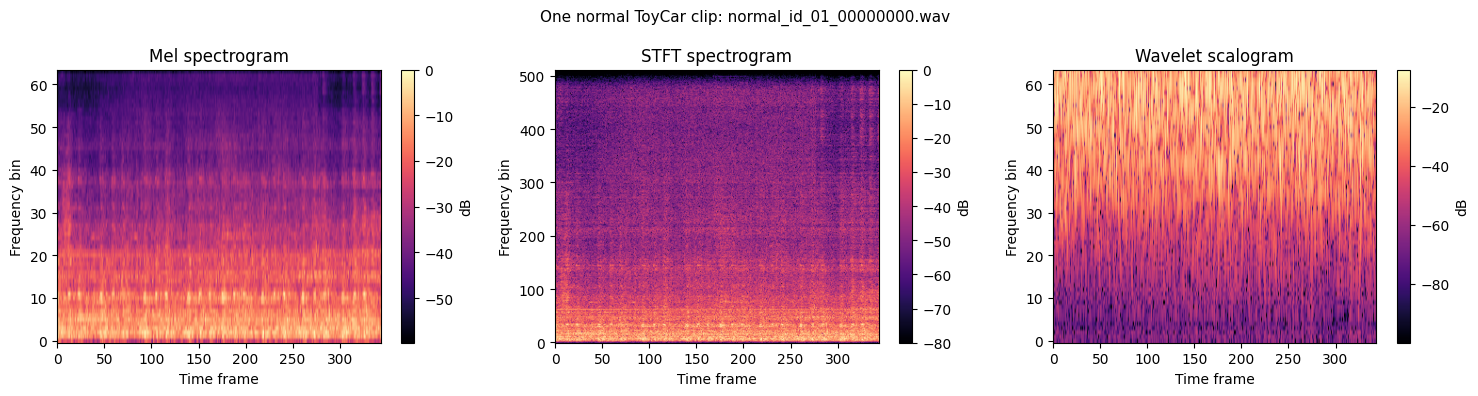

In [9]:
from config import N_MELS, STFT_BINS, N_SCALES

# Recover the 2-D spectrogram shape from the flat row vector.
# The time axis T is whatever was captured; we derive it from the total length.
T_mel  = X_mel_train.shape[1]  // N_MELS
T_stft = X_stft_train.shape[1] // STFT_BINS
T_wav  = X_wav_train.shape[1]  // N_SCALES

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_spectrogram(X_mel_train[0].reshape(N_MELS, T_mel),     title="Mel spectrogram",   ax=axes[0])
plot_spectrogram(X_stft_train[0].reshape(STFT_BINS, T_stft), title="STFT spectrogram",  ax=axes[1])
plot_spectrogram(X_wav_train[0].reshape(N_SCALES, T_wav),   title="Wavelet scalogram", ax=axes[2])

fig.suptitle(f"One normal ToyCar clip: {train_files[0].name}", fontsize=11)
fig.tight_layout()
plt.show()